Setup   

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Configuration

In [2]:
root_dir = "/home/aarya/Projects/LIDAR_RADAR/RWUDataset/CBuilding/csv"

folder_clear = os.path.join(root_dir, "c_building_pedestrian_clear_anon")
folder_fog   = os.path.join(root_dir, "c_building_pedestrian_fog_anon")

sensors = ["velodyne", "blickfeld", "radar"]

# Frame used for all "single frame" inspections below
frame_idx  = 200
frame_name = f"{frame_idx:06d}.csv"

Data Loading Utilities

In [3]:
def load_pointcloud(file_path):
    """Load a point cloud from .csv/.txt (whitespace-delimited) or .bin (KITTI-style)."""
    ext = os.path.splitext(file_path)[1].lower()

    if ext in [".txt", ".csv"]:
        data = np.loadtxt(file_path)
    elif ext == ".bin":
        raw = np.fromfile(file_path, dtype=np.float32)
        if len(raw) % 4 == 0:
            data = raw.reshape(-1, 4)
        elif len(raw) % 3 == 0:
            data = raw.reshape(-1, 3)
        else:
            raise ValueError(f"Unsupported BIN format: {file_path}")
    else:
        raise ValueError(f"Unsupported file type: {file_path}")

    if data.ndim == 1:
        data = data.reshape(1, -1)

    return data


def get_frames(folder):
    """Sorted list of frame filenames in a sensor folder."""
    if not os.path.exists(folder):
        return []
    return sorted(
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    )


def to_distance(data):
    """Euclidean distance (x, y, z) for every point."""
    return np.linalg.norm(data[:, :3], axis=1)


def to_dist_intensity(data):
    """Distance + per-frame-normalized intensity (falls back to all-ones if no intensity col)."""
    dist = to_distance(data)

    if data.shape[1] >= 4:
        intensity = np.nan_to_num(data[:, 3].astype(float), nan=0.0, posinf=0.0, neginf=0.0)
        max_int = np.max(intensity)
        intensity = intensity / max_int if max_int > 0 else np.zeros_like(intensity)
    else:
        intensity = np.ones(len(dist))

    return dist, intensity

Single-Frame Inspection

In [4]:
print("=" * 50)
print(f"  DATASET PROPERTIES FOR FRAME: {frame_name}")
print("=" * 50)

for sensor in sensors:
    print(f"\n--- SENSOR: {sensor.upper()} ---")

    for label, folder in [("Clear", folder_clear), ("Fog", folder_fog)]:
        path = os.path.join(folder, sensor, frame_name)
        if not os.path.exists(path):
            print(f"  [{label}] File not found at {path}")
            continue

        data = load_pointcloud(path)
        print(f"  [{label}] shape={data.shape}, points={data.shape[0]}, "
              f"features={data.shape[1]}, dtype={data.dtype}")
        print(f"           first row: {data[0]}")

  DATASET PROPERTIES FOR FRAME: 000200.csv

--- SENSOR: VELODYNE ---
  [Clear] shape=(28128, 6), points=28128, features=6, dtype=float64
           first row: [-0.72215205 -0.02282065 -0.19359665  7.          0.         -0.09940982]
  [Fog] shape=(23253, 6), points=23253, features=6, dtype=float64
           first row: [ 2.15916705  1.20523465 -0.66257679  6.          0.         -0.09950471]

--- SENSOR: BLICKFELD ---
  [Clear] shape=(9434, 5), points=9434, features=5, dtype=float64
           first row: [ 1.00469445e+01 -6.01713827e+00 -4.55556861e-01  3.56200000e+03
  0.00000000e+00]
  [Fog] shape=(8260, 5), points=8260, features=5, dtype=float64
           first row: [ 10.06032969  -6.02519645  -0.45579076 194.           0.        ]

--- SENSOR: RADAR ---
  [Clear] shape=(370, 5), points=370, features=5, dtype=float64
           first row: [ 0.45711049 -2.03574723 -0.22147655 -1.80251002 22.95885849]
  [Fog] shape=(371, 5), points=371, features=5, dtype=float64
           first row:

Distance Distribution — Single Frame

In [5]:
def plot_distance_overlay(sensor_name, dist_range=(0, 25), bins=100):
    path_clear = os.path.join(folder_clear, sensor_name, frame_name)
    path_fog   = os.path.join(folder_fog, sensor_name, frame_name)

    dist_clear = to_distance(load_pointcloud(path_clear))
    dist_fog   = to_distance(load_pointcloud(path_fog))

    plt.figure(figsize=(10, 5))
    plt.hist(dist_clear, bins=bins, range=dist_range, alpha=0.5, label="Clear", color="blue")
    plt.hist(dist_fog,   bins=bins, range=dist_range, alpha=0.5, label="Fog",   color="red")
    plt.title(f"Distance Histogram (Overlay): {sensor_name.upper()}")
    plt.xlabel("Distance (m)")
    plt.ylabel("Number of Point Reflections")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


def plot_distance_stacked(sensor_name, dist_range=(0, 25), bins=100):
    path_clear = os.path.join(folder_clear, sensor_name, frame_name)
    path_fog   = os.path.join(folder_fog, sensor_name, frame_name)

    dist_clear = to_distance(load_pointcloud(path_clear))
    dist_fog   = to_distance(load_pointcloud(path_fog))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

    ax1.hist(dist_clear, bins=bins, range=dist_range, color="blue", alpha=0.7)
    ax1.set_title(f"{sensor_name.upper()} - Clear Scene")
    ax1.set_ylabel("Number of Points")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2.hist(dist_fog, bins=bins, range=dist_range, color="red", alpha=0.7)
    ax2.set_title(f"{sensor_name.upper()} - Foggy Scene")
    ax2.set_xlabel("Distance (m)")
    ax2.set_ylabel("Number of Points")
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

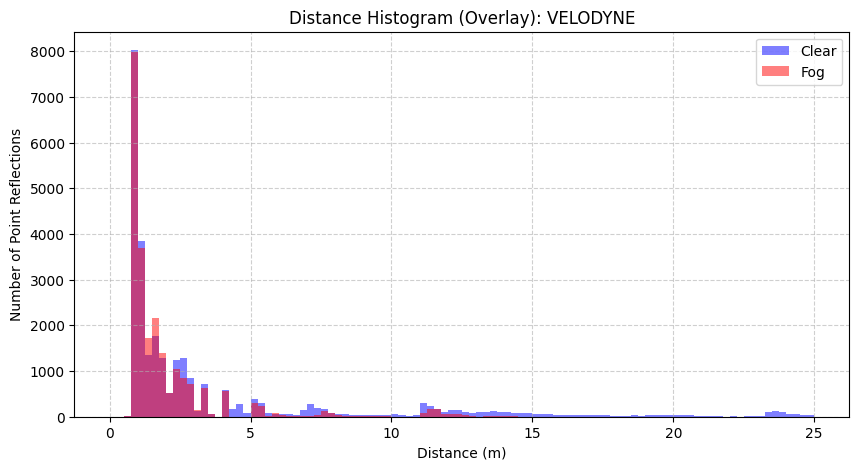

In [6]:
# Quick overlay preview (Velodyne)
plot_distance_overlay("velodyne")

Analyzing Velodyne...


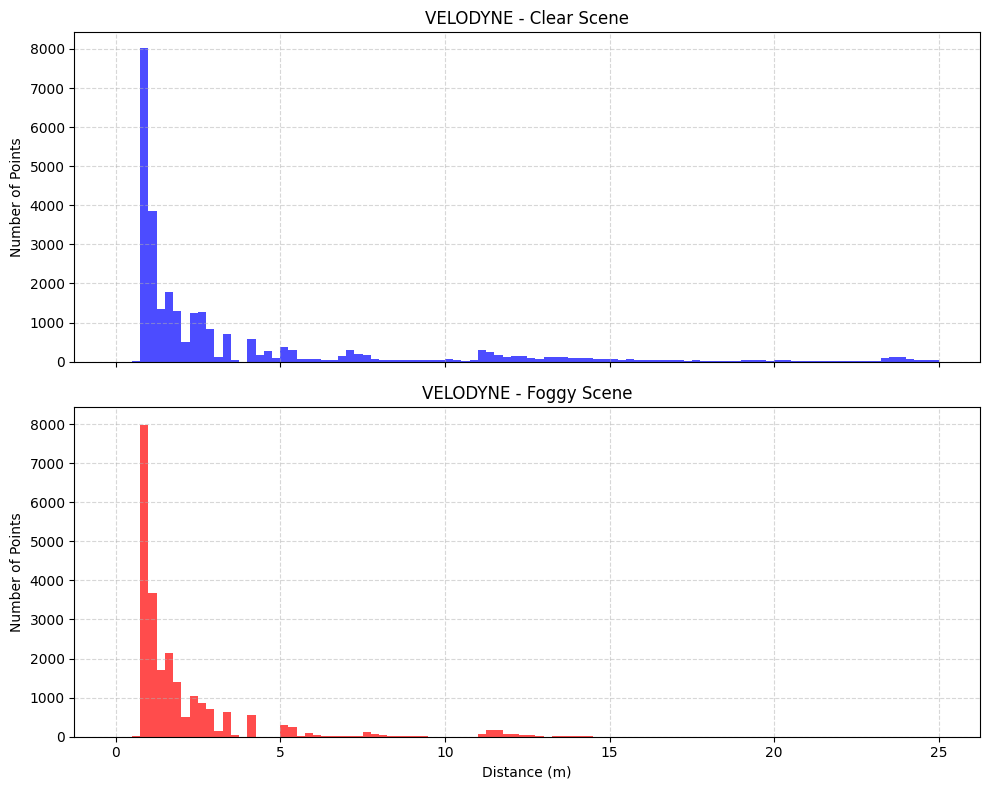

Analyzing Blickfeld...


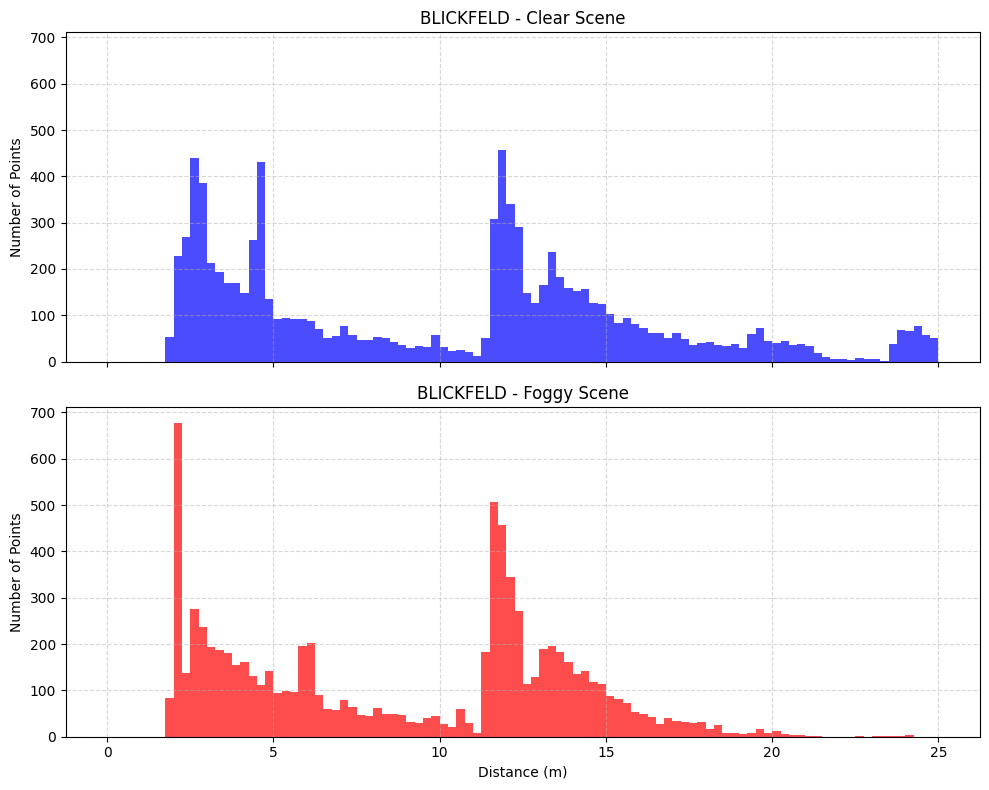

Analyzing Radar...


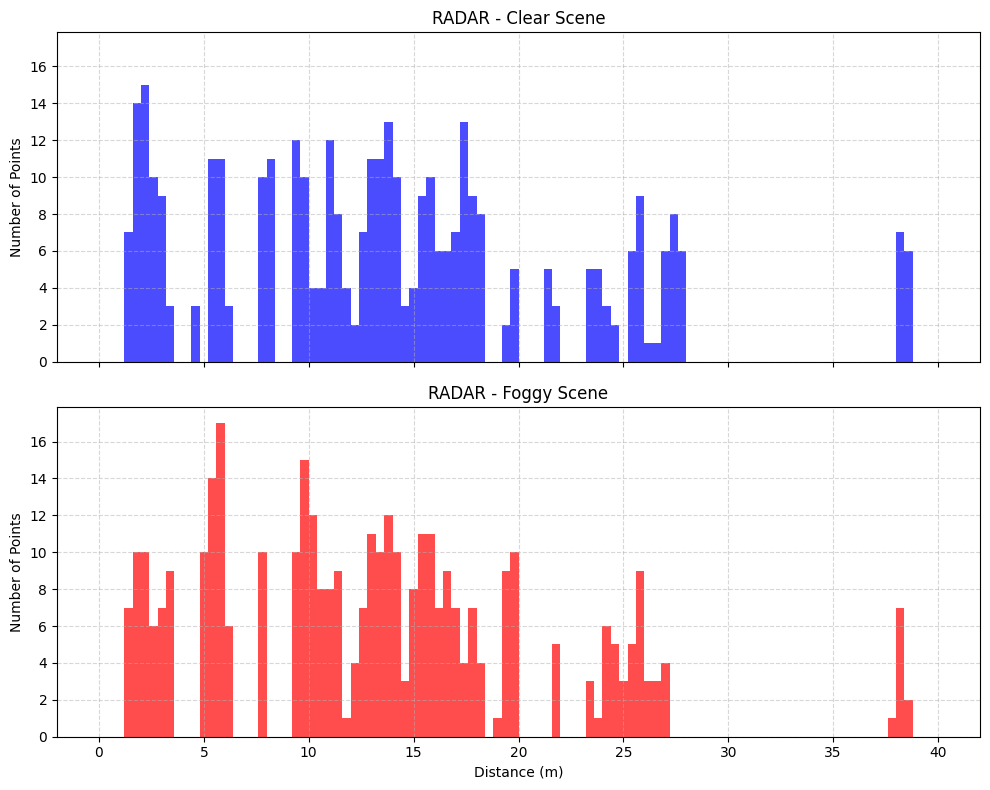

In [7]:
# Side-by-side view, all sensors
for sensor in sensors:
    print(f"Analyzing {sensor.capitalize()}...")
    plot_distance_stacked(sensor, dist_range=(0, 25) if sensor != "radar" else (0, 40))

## 5. Distance Retention — Full Dataset

For every frame with both a clear and foggy capture, bin points by distance and
compute `fog_count / clear_count` per bin. Aggregated two ways:

- **Global retention** — pooled counts across the whole sequence
- **Mean ± std retention** — per-frame retention curves averaged, showing variance

In [8]:
def distance_retention_analysis(sensor_name, max_dist=50, bin_size=0.5, plot=True):
    clear_dir = os.path.join(folder_clear, sensor_name)
    fog_dir   = os.path.join(folder_fog, sensor_name)

    bins = np.arange(0, max_dist + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    frames = get_frames(clear_dir)
    if not frames:
        print(f"No frames found for {sensor_name}.")
        return None

    clear_total = np.zeros(len(bins) - 1)
    fog_total   = np.zeros(len(bins) - 1)
    all_retentions = []
    valid_frames = 0

    for frame in frames:
        clear_path = os.path.join(clear_dir, frame)
        fog_path   = os.path.join(fog_dir, frame)
        if not os.path.exists(fog_path):
            continue

        try:
            dist_clear = to_distance(load_pointcloud(clear_path))
            dist_fog   = to_distance(load_pointcloud(fog_path))
        except Exception as e:
            print(f"Skipping {frame}: {e}")
            continue

        hist_clear, _ = np.histogram(dist_clear, bins=bins)
        hist_fog, _   = np.histogram(dist_fog, bins=bins)

        clear_total += hist_clear
        fog_total   += hist_fog

        with np.errstate(divide="ignore", invalid="ignore"):
            all_retentions.append(np.where(hist_clear > 0, hist_fog / hist_clear, np.nan))

        valid_frames += 1

    if valid_frames == 0:
        print(f"No valid frame pairs for {sensor_name}.")
        return None

    all_retentions = np.array(all_retentions)

    with np.errstate(divide="ignore", invalid="ignore"):
        global_retention = np.where(clear_total > 0, fog_total / clear_total, np.nan)

    mean_retention = np.nanmean(all_retentions, axis=0)
    std_retention  = np.nanstd(all_retentions, axis=0)

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(bin_centers, global_retention, linewidth=2, label="Global Retention")
        plt.axhline(1.0, linestyle="--", alpha=0.5)
        plt.title(f"{sensor_name.upper()} - Global Distance Retention")
        plt.xlabel("Distance (m)"); plt.ylabel("Fog / Clear")
        plt.ylim(0, 1.2); plt.grid(True); plt.legend()
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.plot(bin_centers, mean_retention, linewidth=2, label="Mean Retention")
        plt.fill_between(bin_centers, mean_retention - std_retention,
                          mean_retention + std_retention, alpha=0.3, label="±1 Std")
        plt.axhline(1.0, linestyle="--", alpha=0.5)
        plt.title(f"{sensor_name.upper()} - Mean Distance Retention ± Variance")
        plt.xlabel("Distance (m)"); plt.ylabel("Retention")
        plt.ylim(0, 1.2); plt.grid(True); plt.legend()
        plt.show()

    print(f"--- {sensor_name.upper()} SUMMARY ---")
    print("Valid frame pairs:", valid_frames)
    below_50 = np.where(global_retention < 0.5)[0]
    if len(below_50) > 0:
        print("50% retention distance:", bin_centers[below_50[0]], "m")
    else:
        print("Retention never drops below 50%")
    print("Mean retention:", np.nanmean(global_retention))
    print("Mean std:", np.nanmean(std_retention))

    return bin_centers, global_retention, mean_retention, std_retention


Analyzing: VELODYNE


/tmp/ipykernel_23064/2330563634.py:51: RuntimeWarning: Mean of empty slice
  mean_retention = np.nanmean(all_retentions, axis=0)
/home/aarya/Projects/LIDAR_RADAR/lidar_t1_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


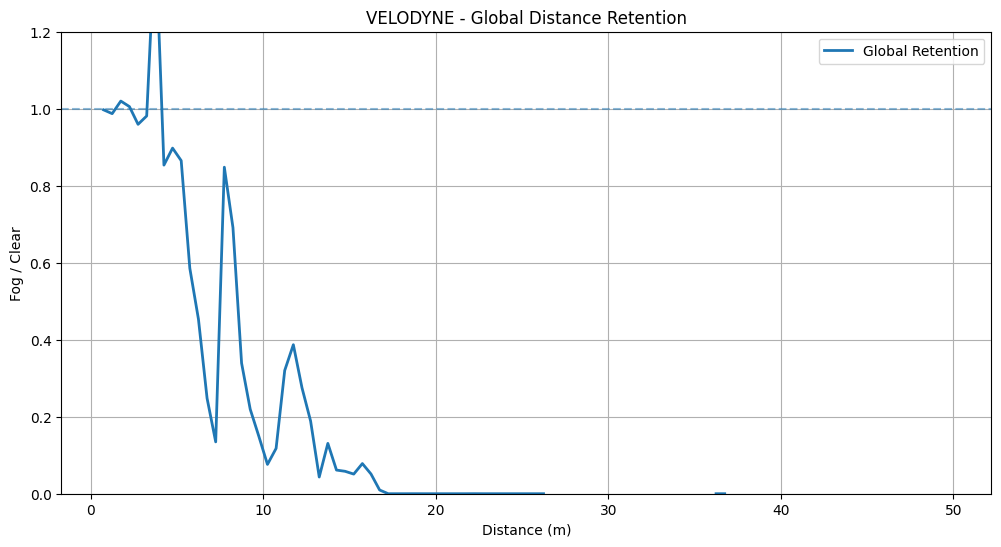

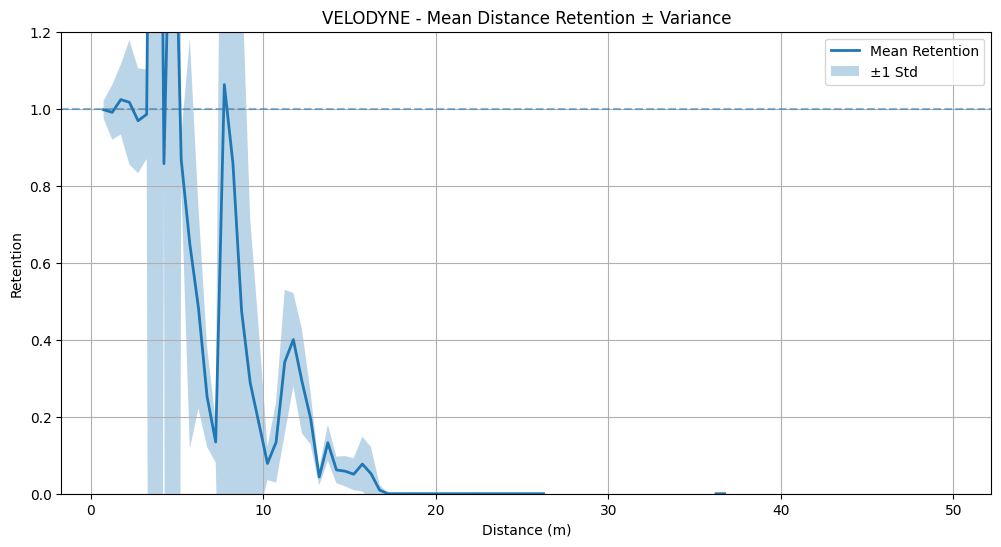

--- VELODYNE SUMMARY ---
Valid frame pairs: 500
50% retention distance: 6.25 m
Mean retention: 0.2589883409640807
Mean std: 0.4772638317027634

Analyzing: BLICKFELD


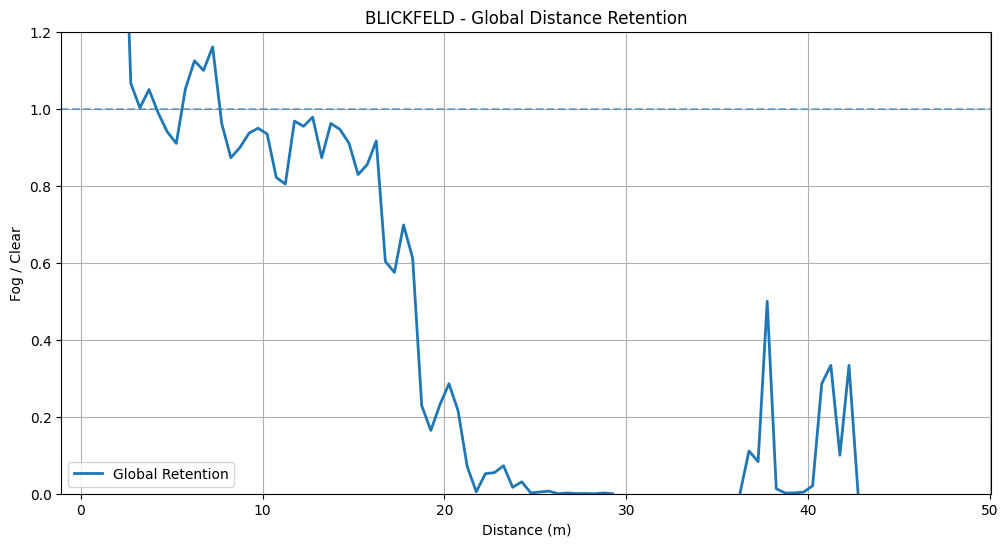

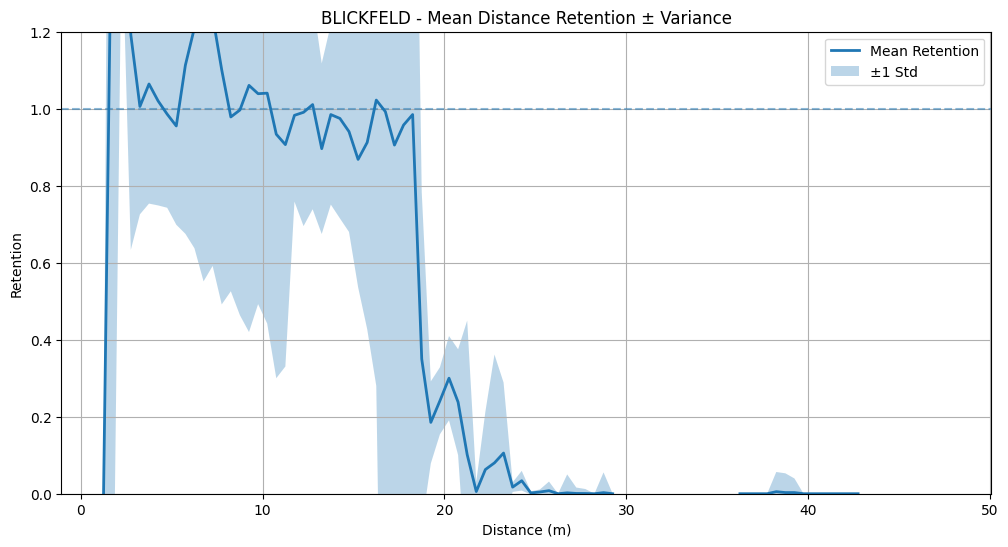

--- BLICKFELD SUMMARY ---
Valid frame pairs: 500
50% retention distance: 18.75 m
Mean retention: 0.532992263277903
Mean std: 0.3116578363309703

Analyzing: RADAR


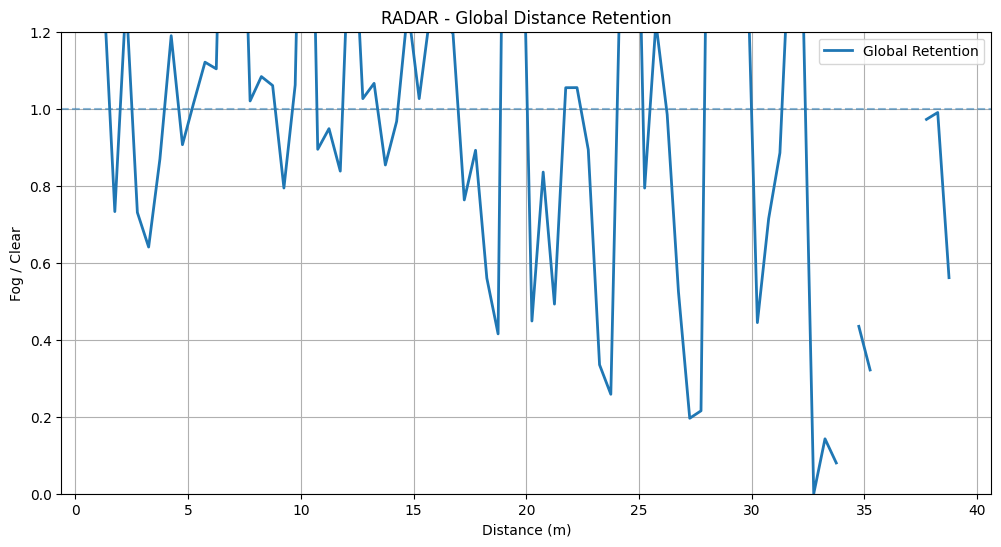

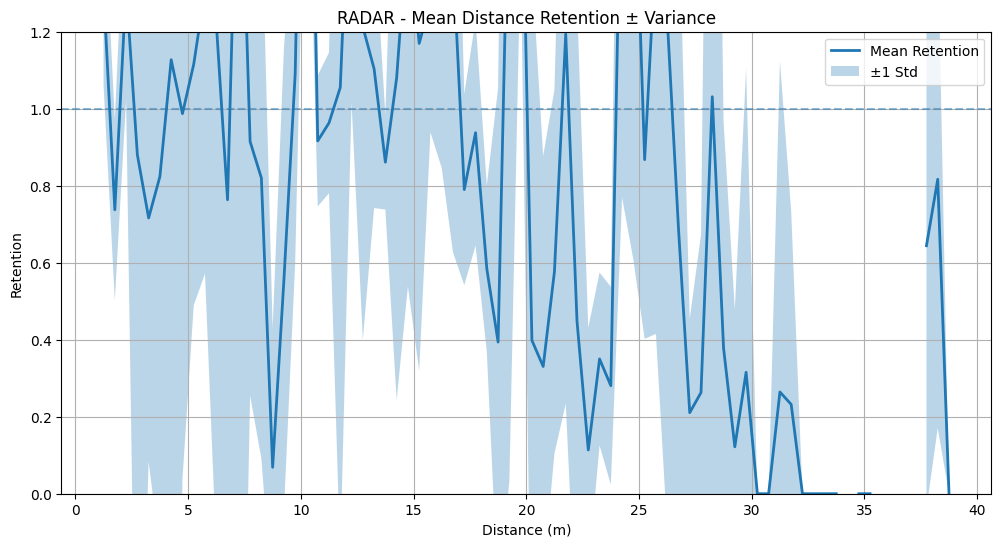

--- RADAR SUMMARY ---
Valid frame pairs: 500
50% retention distance: 18.75 m
Mean retention: 1.057204713902175
Mean std: 0.6965718149918583


In [9]:
for sensor in sensors:
    print("\n" + "=" * 35)
    print("Analyzing:", sensor.upper())
    print("=" * 35)
    distance_retention_analysis(sensor)

## 6. Intensity Distribution — Single Frame

Histogram shows the shape of the distribution; boxplot makes the quartile shift
easier to read at a glance. Radar is skipped here since it may not carry a
meaningful intensity channel.

In [11]:
def plot_intensity_histogram(sensor_name, bins=50):
    path_clear = os.path.join(folder_clear, sensor_name, frame_name)
    path_fog   = os.path.join(folder_fog, sensor_name, frame_name)

    int_clear = load_pointcloud(path_clear)[:, 3]
    int_fog   = load_pointcloud(path_fog)[:, 3]

    plt.figure(figsize=(12, 5))
    plt.hist(int_clear, bins=bins, alpha=0.6, label="Clear", color="blue", density=True)
    plt.hist(int_fog,   bins=bins, alpha=0.6, label="Fog",   color="red",  density=True)
    plt.title(f"Intensity Distribution: {sensor_name.upper()}")
    plt.xlabel("Intensity Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


def plot_intensity_boxplot(sensor_name):
    path_clear = os.path.join(folder_clear, sensor_name, frame_name)
    path_fog   = os.path.join(folder_fog, sensor_name, frame_name)

    int_clear = load_pointcloud(path_clear)[:, 3]
    int_fog   = load_pointcloud(path_fog)[:, 3]

    plt.figure(figsize=(8, 6))
    plt.boxplot([int_clear, int_fog], labels=["Clear", "Fog"])
    plt.title(f"Intensity Distribution: {sensor_name.upper()}")
    plt.ylabel("Intensity Value")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

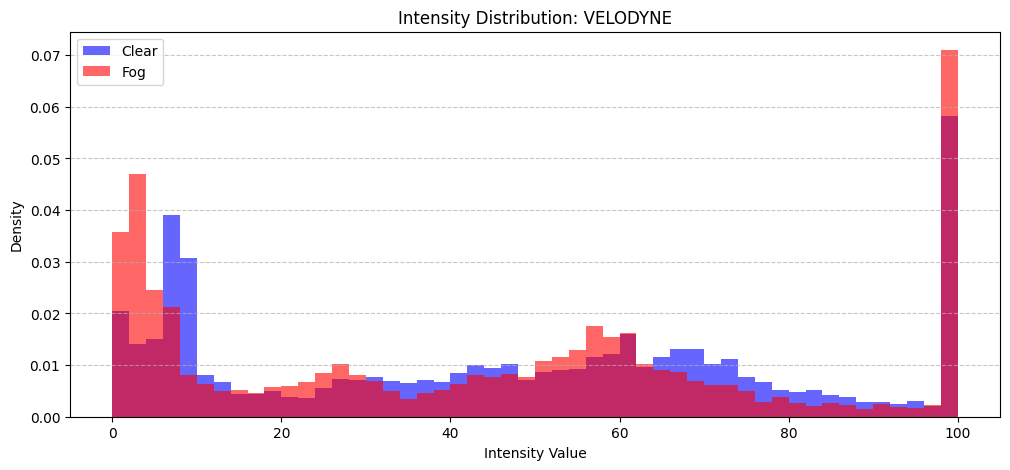

/tmp/ipykernel_23064/663686703.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([int_clear, int_fog], labels=["Clear", "Fog"])


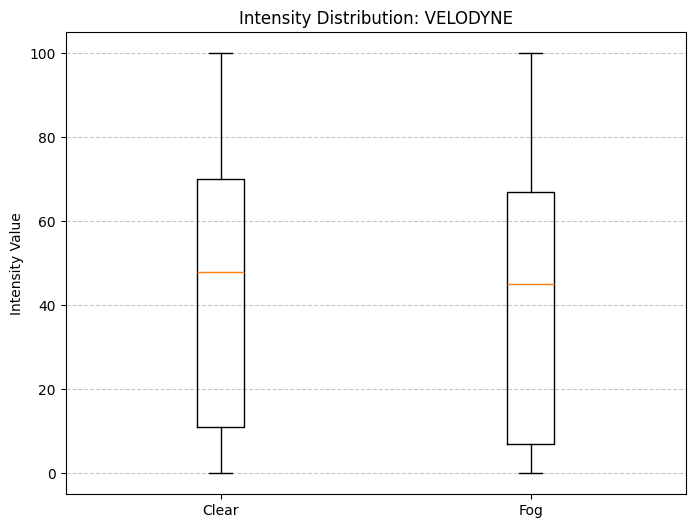

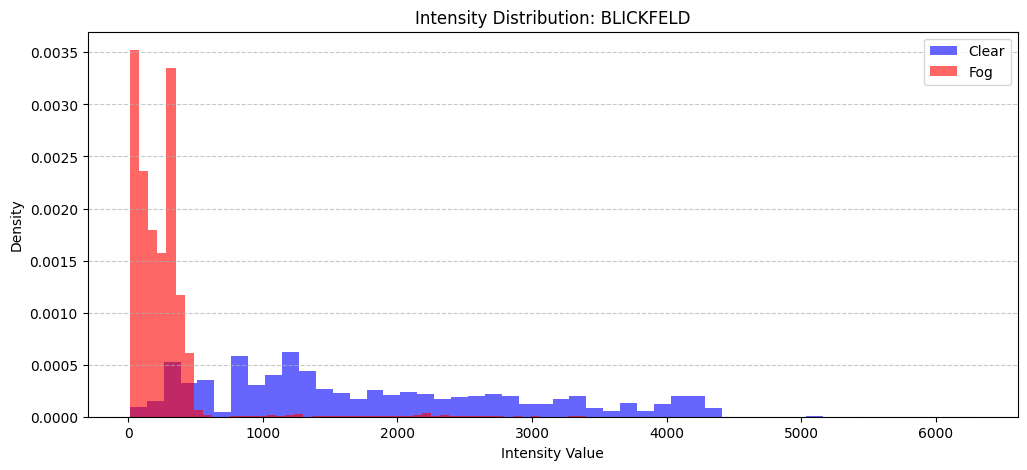

/tmp/ipykernel_23064/663686703.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([int_clear, int_fog], labels=["Clear", "Fog"])


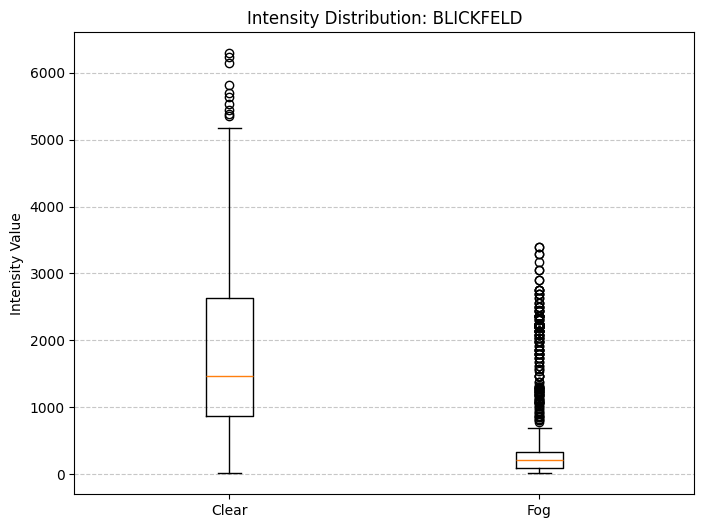

In [12]:
for sensor in ["velodyne", "blickfeld"]:
    plot_intensity_histogram(sensor)
    plot_intensity_boxplot(sensor)

## 7. Intensity Retention — Full Dataset (Normalized)

Same idea as Section 5, but for per-frame-normalized intensity instead of point
count: mean intensity per distance bin, fog vs. clear, both globally (pooled) and
per-frame (mean ± std).

In [13]:
def intensity_retention_analysis(sensor_name, max_dist=50, bin_size=1.0, plot=True):
    clear_dir = os.path.join(folder_clear, sensor_name)
    fog_dir   = os.path.join(folder_fog, sensor_name)

    bins = np.arange(0, max_dist + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    frames = get_frames(clear_dir)
    if not frames:
        print(f"No frames found for {sensor_name}.")
        return None

    all_frame_retentions = []
    global_clear_sum = np.zeros(len(bins) - 1)
    global_fog_sum   = np.zeros(len(bins) - 1)
    global_clear_count = np.zeros(len(bins) - 1)
    global_fog_count   = np.zeros(len(bins) - 1)
    valid_frames = 0

    for frame in frames:
        clear_path = os.path.join(clear_dir, frame)
        fog_path   = os.path.join(fog_dir, frame)
        if not os.path.exists(fog_path):
            continue

        try:
            dist_clear, int_clear = to_dist_intensity(load_pointcloud(clear_path))
            dist_fog,   int_fog   = to_dist_intensity(load_pointcloud(fog_path))
        except Exception:
            continue

        mask_c = (dist_clear >= 0) & (dist_clear <= max_dist)
        mask_f = (dist_fog >= 0) & (dist_fog <= max_dist)
        dist_clear, int_clear = dist_clear[mask_c], int_clear[mask_c]
        dist_fog,   int_fog   = dist_fog[mask_f],   int_fog[mask_f]

        clear_sum,   _ = np.histogram(dist_clear, bins=bins, weights=int_clear)
        fog_sum,     _ = np.histogram(dist_fog,   bins=bins, weights=int_fog)
        clear_count, _ = np.histogram(dist_clear, bins=bins)
        fog_count,   _ = np.histogram(dist_fog,   bins=bins)

        mean_clear = np.where(clear_count > 0, clear_sum / clear_count, np.nan)
        mean_fog   = np.where(fog_count > 0,   fog_sum / fog_count,   np.nan)

        frame_retention = np.where(
            ~np.isnan(mean_clear) & (mean_clear > 0), mean_fog / mean_clear, np.nan
        )
        all_frame_retentions.append(frame_retention)

        global_clear_sum += np.nan_to_num(clear_sum)
        global_fog_sum   += np.nan_to_num(fog_sum)
        global_clear_count += clear_count
        global_fog_count   += fog_count
        valid_frames += 1

    if valid_frames == 0:
        print(f"No valid frames for {sensor_name}.")
        return None

    all_frame_retentions = np.array(all_frame_retentions)

    global_mean_clear = np.where(global_clear_count > 0, global_clear_sum / global_clear_count, np.nan)
    global_mean_fog   = np.where(global_fog_count > 0,   global_fog_sum / global_fog_count,   np.nan)
    global_retention  = np.where(
        ~np.isnan(global_mean_clear) & (global_mean_clear > 0),
        global_mean_fog / global_mean_clear, np.nan
    )

    mean_retention = np.nanmean(all_frame_retentions, axis=0)
    std_retention  = np.nanstd(all_frame_retentions, axis=0)

    if plot:
        plt.figure(figsize=(12, 6))
        plt.plot(bin_centers, global_retention, linewidth=2, label="Global Intensity Retention")
        plt.axhline(1.0, linestyle="--", alpha=0.5)
        plt.title(f"{sensor_name.upper()} - Intensity Retention vs Distance")
        plt.xlabel("Distance (m)"); plt.ylabel("Fog / Clear")
        plt.ylim(0, 1.2); plt.grid(True); plt.legend()
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.plot(bin_centers, mean_retention, linewidth=2, label="Mean Retention")
        plt.fill_between(bin_centers, mean_retention - std_retention,
                          mean_retention + std_retention, alpha=0.3, label="±1 Std")
        plt.axhline(1.0, linestyle="--", alpha=0.5)
        plt.title(f"{sensor_name.upper()} - Mean Intensity Retention ± Variance")
        plt.xlabel("Distance (m)"); plt.ylabel("Retention")
        plt.ylim(0, 1.2); plt.grid(True); plt.legend()
        plt.show()

    print(f"--- {sensor_name.upper()} SUMMARY ---")
    print("Valid frames:", valid_frames)
    below_50 = np.where(global_retention < 0.5)[0]
    if len(below_50) > 0:
        print("50% retention distance:", bin_centers[below_50[0]], "m")
    else:
        print("Retention never drops below 50%")
    print("Mean retention:", np.nanmean(global_retention))
    print("Mean std:", np.nanmean(std_retention))

    return bin_centers, global_retention, mean_retention, std_retention


Analyzing: VELODYNE


/tmp/ipykernel_23064/1579166311.py:42: RuntimeWarning: invalid value encountered in divide
  mean_clear = np.where(clear_count > 0, clear_sum / clear_count, np.nan)
/tmp/ipykernel_23064/1579166311.py:43: RuntimeWarning: invalid value encountered in divide
  mean_fog   = np.where(fog_count > 0,   fog_sum / fog_count,   np.nan)
/tmp/ipykernel_23064/1579166311.py:62: RuntimeWarning: invalid value encountered in divide
  global_mean_clear = np.where(global_clear_count > 0, global_clear_sum / global_clear_count, np.nan)
/tmp/ipykernel_23064/1579166311.py:63: RuntimeWarning: invalid value encountered in divide
  global_mean_fog   = np.where(global_fog_count > 0,   global_fog_sum / global_fog_count,   np.nan)
/tmp/ipykernel_23064/1579166311.py:69: RuntimeWarning: Mean of empty slice
  mean_retention = np.nanmean(all_frame_retentions, axis=0)


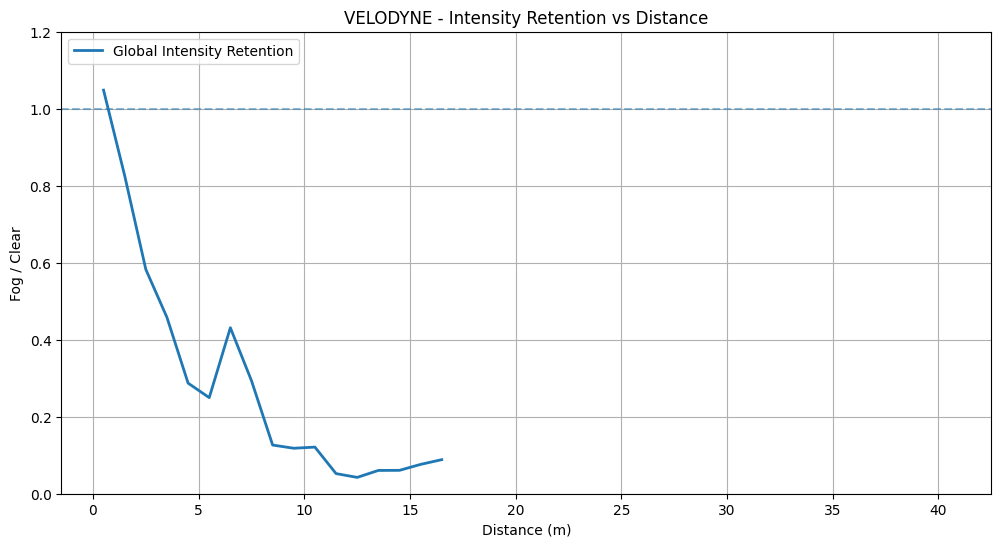

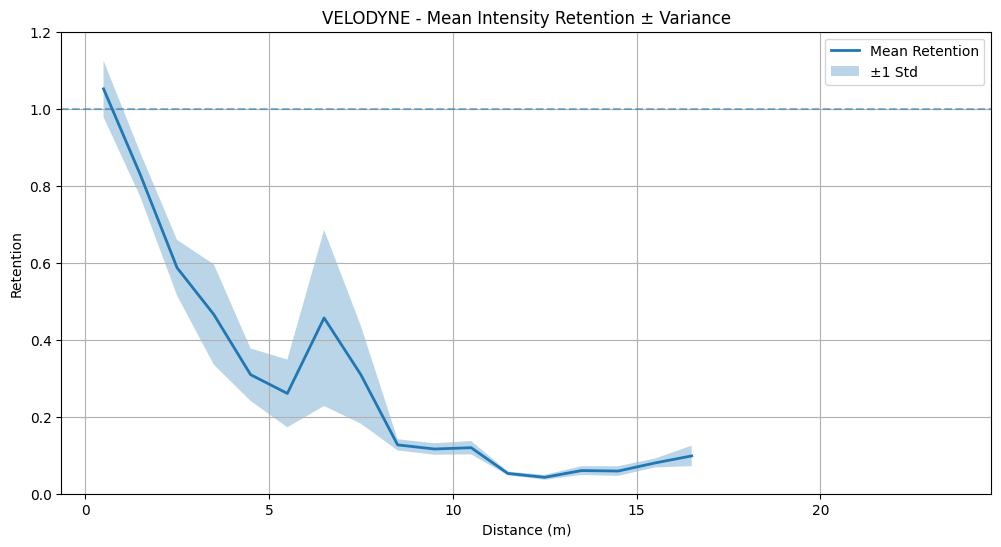

--- VELODYNE SUMMARY ---
Valid frames: 500
50% retention distance: 3.5 m
Mean retention: 0.6855704098354811
Mean std: 0.048284766064086285

Analyzing: BLICKFELD


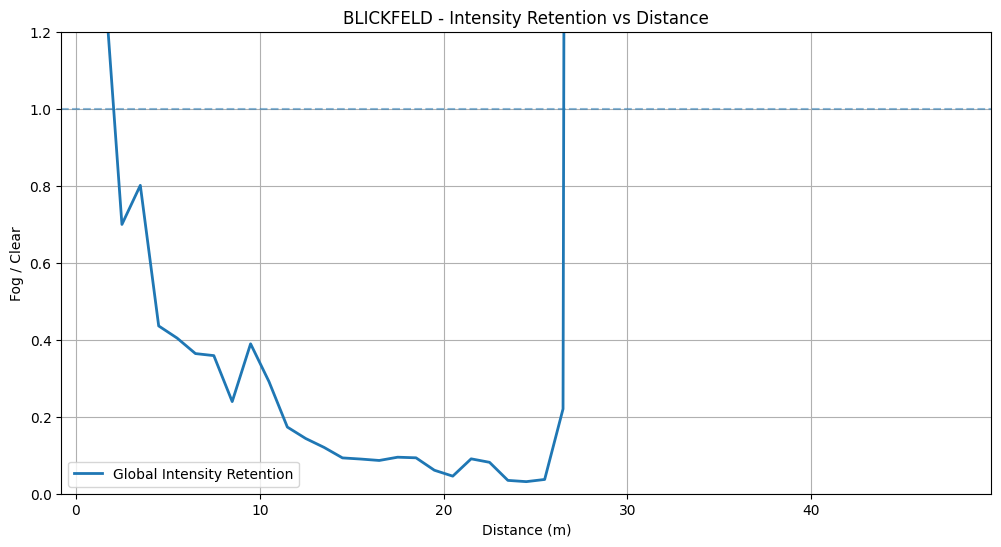

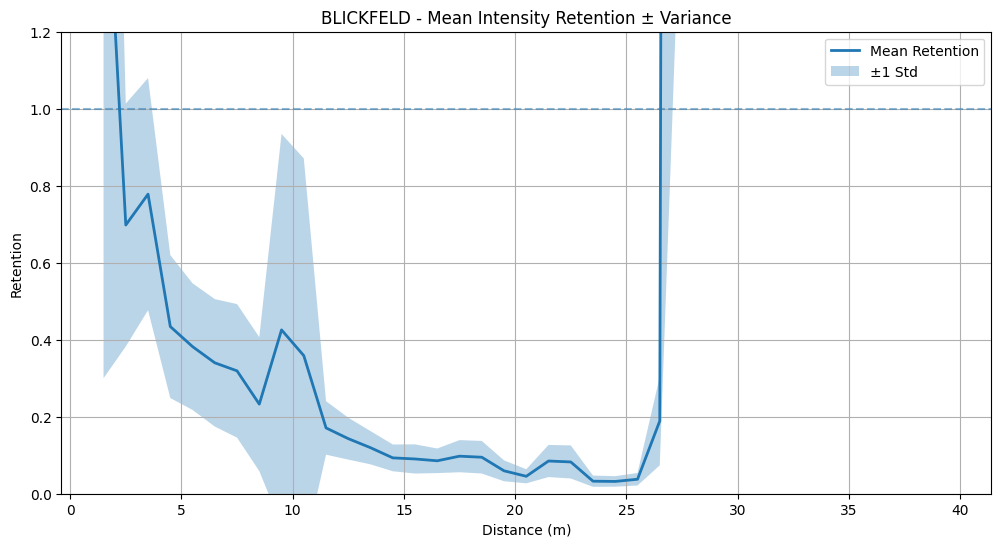

--- BLICKFELD SUMMARY ---
Valid frames: 500
50% retention distance: 4.5 m
Mean retention: 2.2330893467947255
Mean std: 0.9880537304775902


In [16]:
for sensor in sensors[:-1]:
    print("\n" + "=" * 35)
    print("Analyzing:", sensor.upper())
    print("=" * 35)
    intensity_retention_analysis(sensor)

## 8. Overall Intensity Change Summary

Single sequence-wide number per sensor: mean normalized intensity, clear vs. fog,
and the % change. Radar excluded (no meaningful intensity channel).

In [17]:
print("=" * 50)
print("  OVERALL INTENSITY CHANGE SUMMARY (%)")
print("=" * 50)

for sensor_name in ["velodyne", "blickfeld"]:
    clear_dir = os.path.join(folder_clear, sensor_name)
    fog_dir   = os.path.join(folder_fog, sensor_name)
    frames    = get_frames(clear_dir)

    total_clear_sum, total_clear_n = 0.0, 0
    total_fog_sum,   total_fog_n   = 0.0, 0

    for frame in frames:
        clear_path = os.path.join(clear_dir, frame)
        fog_path   = os.path.join(fog_dir, frame)
        if not os.path.exists(fog_path):
            continue
        try:
            _, int_clear = to_dist_intensity(load_pointcloud(clear_path))
            _, int_fog   = to_dist_intensity(load_pointcloud(fog_path))
            total_clear_sum += np.sum(int_clear); total_clear_n += len(int_clear)
            total_fog_sum   += np.sum(int_fog);   total_fog_n   += len(int_fog)
        except Exception:
            continue

    if total_clear_n > 0 and total_fog_n > 0:
        mean_clear = total_clear_sum / total_clear_n
        mean_fog   = total_fog_sum / total_fog_n
        pct_change = ((mean_fog - mean_clear) / mean_clear) * 100

        print(f"\n--- {sensor_name.upper()} ---")
        print(f"  Clear Mean Normalized Intensity : {mean_clear:.4f}")
        print(f"  Fog Mean Normalized Intensity   : {mean_fog:.4f}")
        print(f"  Average Intensity Change        : {pct_change:+.2f}%")
    else:
        print(f"\n--- {sensor_name.upper()} --- Data missing or unreadable.")

  OVERALL INTENSITY CHANGE SUMMARY (%)

--- VELODYNE ---
  Clear Mean Normalized Intensity : 0.4486
  Fog Mean Normalized Intensity   : 0.4322
  Average Intensity Change        : -3.67%

--- BLICKFELD ---
  Clear Mean Normalized Intensity : 0.2833
  Fog Mean Normalized Intensity   : 0.0879
  Average Intensity Change        : -68.96%


## 9. Bird's-Eye-View (BEV) Comparisons

Top-down scatter of the same frame, clear vs. fog, colored by intensity
(radar colored by return only, since it has no useful intensity channel).
Per-sensor axis ranges reflect each sensor's realistic field of view.

In [18]:
def plot_bev_comparison(sensor_name, side_range, fwd_range, color_by_intensity=True):
    path_clear = os.path.join(folder_clear, sensor_name, frame_name)
    path_fog   = os.path.join(folder_fog, sensor_name, frame_name)

    data_clear = load_pointcloud(path_clear)
    data_fog   = load_pointcloud(path_fog)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    if color_by_intensity:
        im1 = ax1.scatter(data_clear[:, 0], data_clear[:, 1], c=data_clear[:, 3], s=2, cmap="viridis")
        im2 = ax2.scatter(data_fog[:, 0],   data_fog[:, 1],   c=data_fog[:, 3],   s=2, cmap="magma")
        plt.colorbar(im1, ax=ax1, label="Intensity")
        plt.colorbar(im2, ax=ax2, label="Intensity")
    else:
        ax1.scatter(data_clear[:, 0], data_clear[:, 1], c="blue", s=5, alpha=0.6)
        ax2.scatter(data_fog[:, 0],   data_fog[:, 1],   c="red",  s=5, alpha=0.6)

    ax1.set_title(f"BEV {sensor_name.upper()} - Clear")
    ax2.set_title(f"BEV {sensor_name.upper()} - Fog")
    for ax in (ax1, ax2):
        ax.set_xlim(side_range); ax.set_ylim(fwd_range); ax.set_aspect("equal")
        ax.set_xlabel("X (Left/Right) [m]")
    ax1.set_ylabel("Y (Forward) [m]")

    plt.tight_layout()
    plt.show()

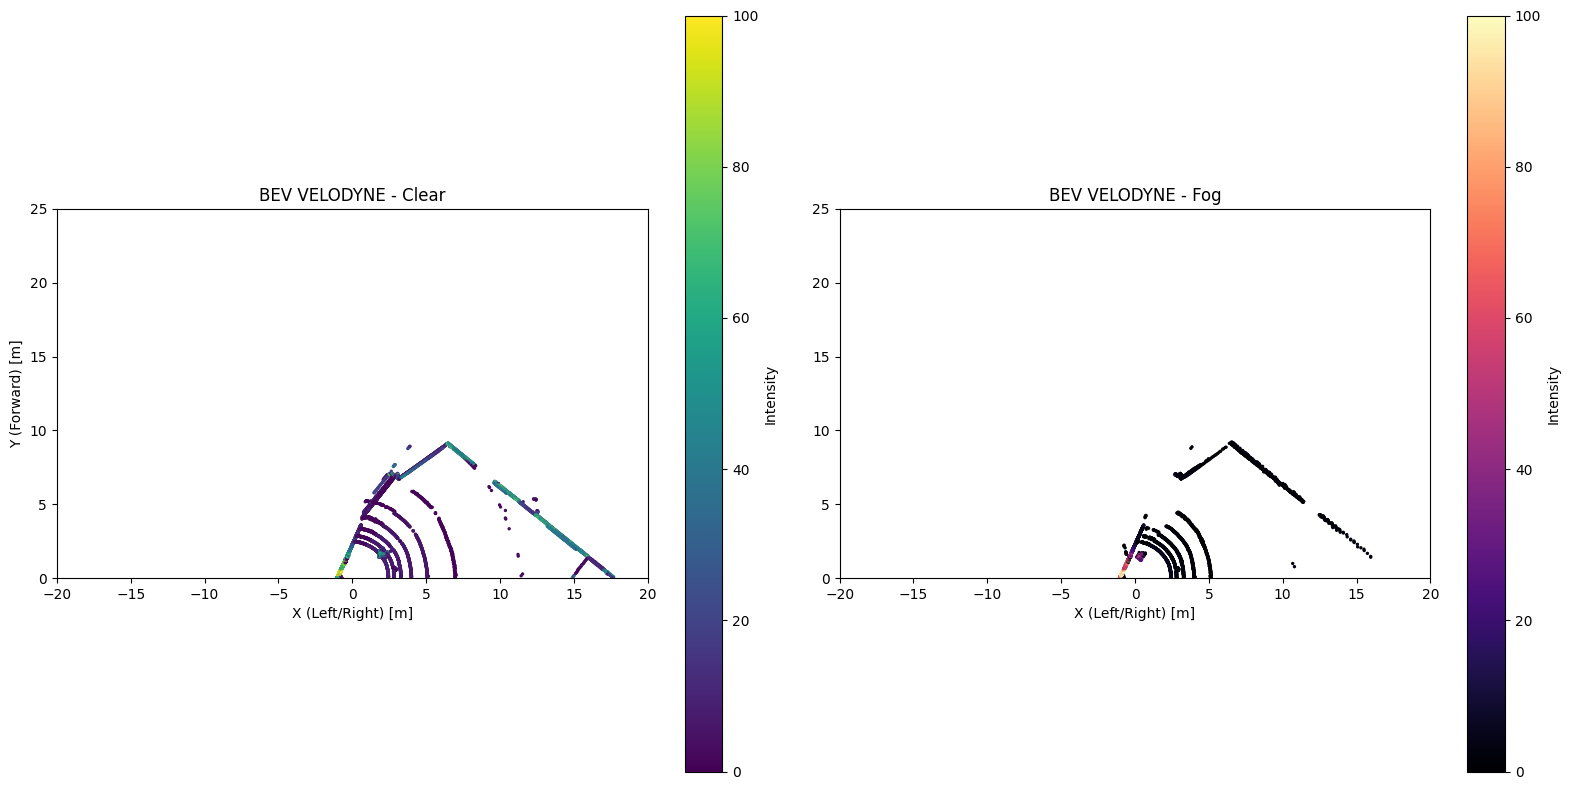

In [19]:
# Velodyne: wide field, look for general density drop
plot_bev_comparison("velodyne", side_range=(-20, 20), fwd_range=(0, 25))

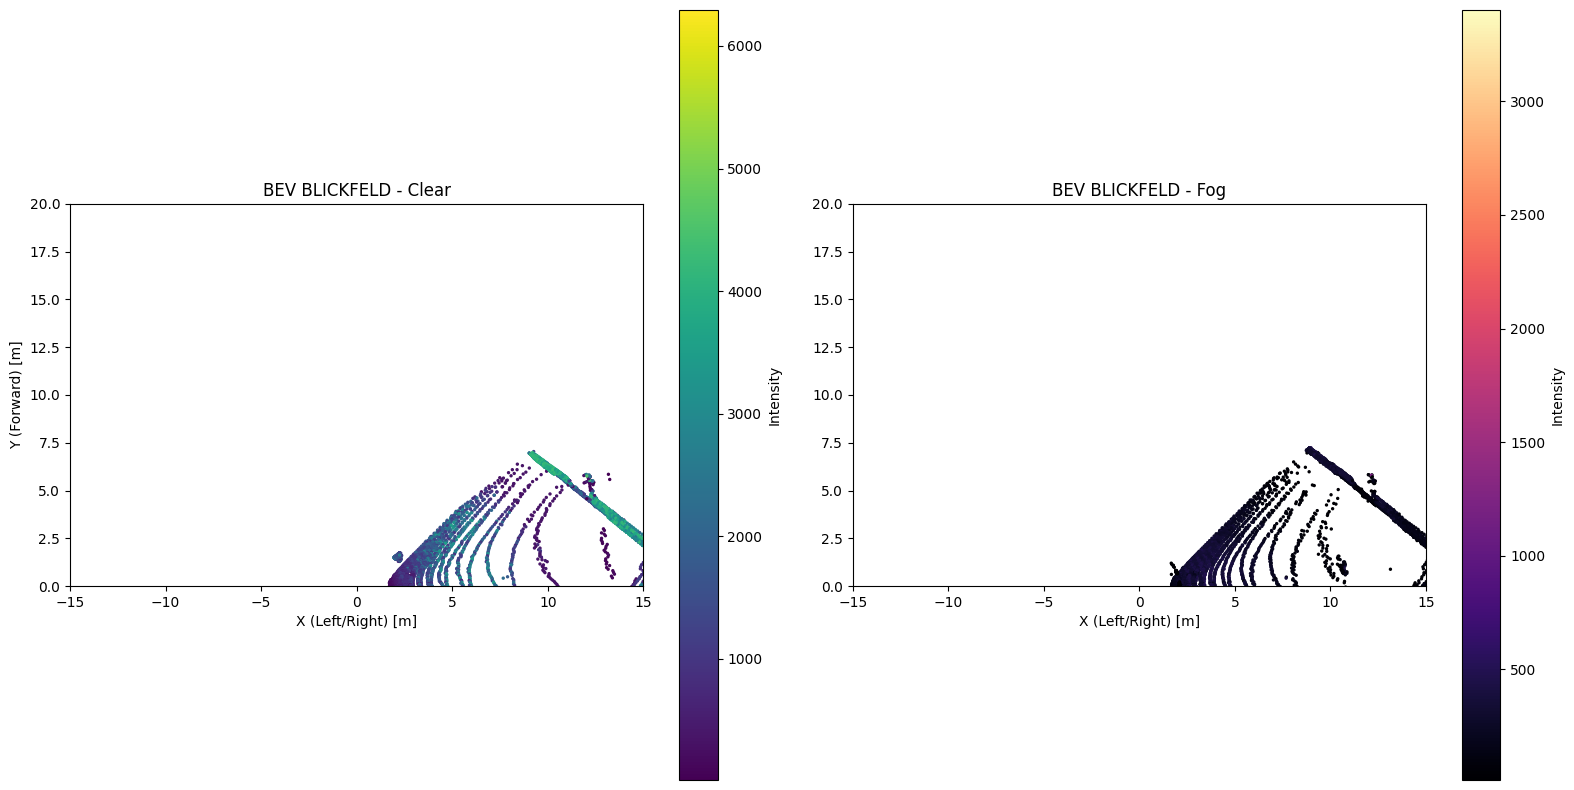

In [20]:
# Blickfeld: narrower field, watch for the "fog wall" artifact near (0,0)
plot_bev_comparison("blickfeld", side_range=(-15, 15), fwd_range=(0, 20))

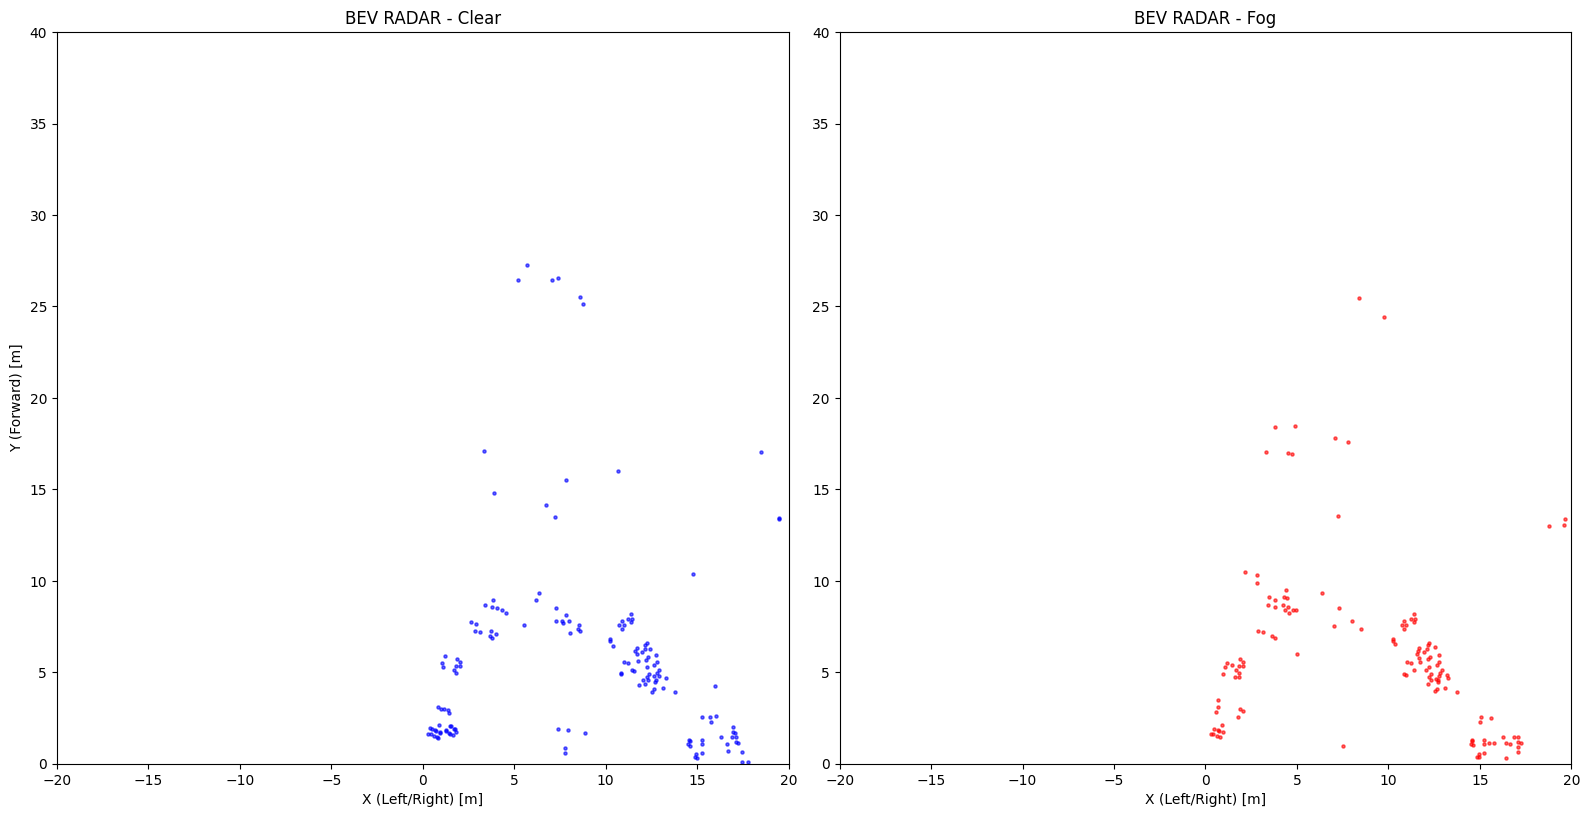

In [21]:
# Radar: longer range, expect returns to stay relatively consistent
plot_bev_comparison("radar", side_range=(-20, 20), fwd_range=(0, 40), color_by_intensity=False)

## 10. Point Count Analysis

First a single-frame snapshot, then the full picture: point count per frame,
clear vs. fog, across the first 500 frames of the sequence — the fastest way to
see whether the fog impact is consistent or highly frame-dependent.

In [22]:
def calculate_point_counts(frame_idx_):
    frame_name_ = f"{frame_idx_:06d}.csv"
    print(f"--- Point Count Analysis (Frame: {frame_name_}) ---")
    print(f"{'Sensor':<12} | {'Clear Count':<12} | {'Fog Count':<12} | {'% Change'}")
    print("-" * 55)

    for sensor in sensors:
        path_clear = os.path.join(folder_clear, sensor, frame_name_)
        path_fog   = os.path.join(folder_fog, sensor, frame_name_)

        count_clear = len(load_pointcloud(path_clear))
        count_fog   = len(load_pointcloud(path_fog))
        pct = ((count_fog - count_clear) / count_clear) * 100

        print(f"{sensor.capitalize():<12} | {count_clear:<12} | {count_fog:<12} | {pct:>+7.2f}%")

calculate_point_counts(0)

--- Point Count Analysis (Frame: 000000.csv) ---
Sensor       | Clear Count  | Fog Count    | % Change
-------------------------------------------------------
Velodyne     | 28129        | 22890        |  -18.62%
Blickfeld    | 9435         | 8233         |  -12.74%
Radar        | 416          | 379          |   -8.89%


In [23]:
num_frames = 500
results = []

print(f"Processing {num_frames} frames... this may take a moment.")

for i in range(num_frames):
    fname = f"{i:06d}.csv"
    frame_stats = {"frame": i}

    for sensor in sensors:
        p_clear = os.path.join(folder_clear, sensor, fname)
        p_fog   = os.path.join(folder_fog, sensor, fname)

        try:
            with open(p_clear, "r") as f:
                frame_stats[f"{sensor}_clear"] = sum(1 for _ in f)
            with open(p_fog, "r") as f:
                frame_stats[f"{sensor}_fog"] = sum(1 for _ in f)
        except FileNotFoundError:
            frame_stats[f"{sensor}_clear"] = np.nan
            frame_stats[f"{sensor}_fog"] = np.nan

    results.append(frame_stats)

df = pd.DataFrame(results)

Processing 500 frames... this may take a moment.


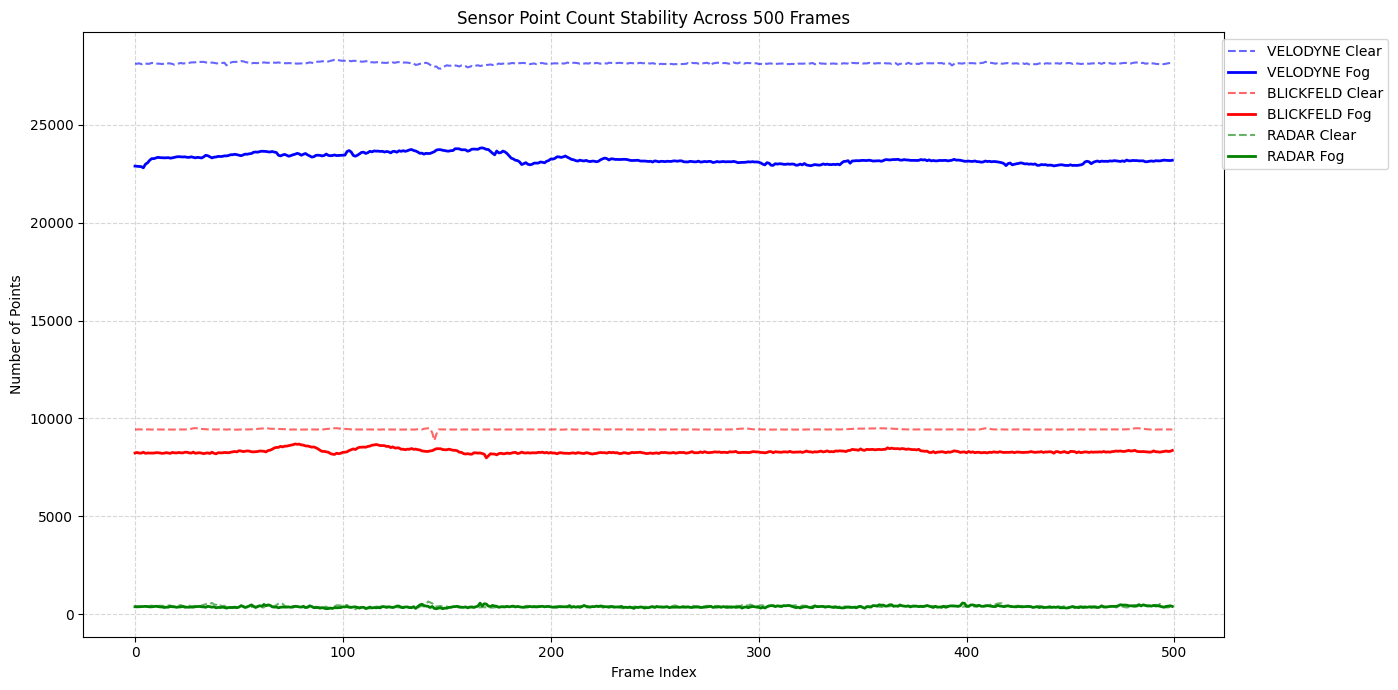


--- Average Point Count Summary ---
VELODYNE  : Clear= 28138, Fog= 23251 | Change:  -17.36%
BLICKFELD : Clear=  9440, Fog=  8311 | Change:  -11.96%
RADAR     : Clear=   395, Fog=   379 | Change:   -4.02%


In [24]:
plt.figure(figsize=(14, 7))
colors = {"velodyne": "blue", "blickfeld": "red", "radar": "green"}

for sensor in sensors:
    plt.plot(df["frame"], df[f"{sensor}_clear"], label=f"{sensor.upper()} Clear",
              color=colors[sensor], linestyle="--", alpha=0.6)
    plt.plot(df["frame"], df[f"{sensor}_fog"], label=f"{sensor.upper()} Fog",
              color=colors[sensor], linestyle="-", linewidth=2)

plt.title("Sensor Point Count Stability Across 500 Frames")
plt.xlabel("Frame Index")
plt.ylabel("Number of Points")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n--- Average Point Count Summary ---")
for s in sensors:
    avg_c = df[f"{s}_clear"].mean()
    avg_f = df[f"{s}_fog"].mean()
    change = ((avg_f - avg_c) / avg_c) * 100
    print(f"{s.upper():<10}: Clear={int(avg_c):>6}, Fog={int(avg_f):>6} | Change: {change:>+7.2f}%")